# Whats Cooking Classification: Predicting cuisine based on recipe text data

Project adapted from Professor Anthony Breitzman at Rowan University, Web and Text Mining 2026.

Dataset info: The following models are trained used the cooking_trainfile.json file. It is a text file comprising of (many) rows of recipes, each with a unique id, an associated cuisine (ex: greek) and a list of ingredients comprising that recipe. 

The goal is that with this data, I can train my model(s) to predict cuisines based on the list of ingredients. After training my models, I will then test them with the cooking_testfile.json, which gives ingredients but not cuisine info. 

 I intend to do a lot of pre-processing, exploratory analysis, model selection/comparison, error analysis and evaluation.

 Thanks for reading!

# How should I measure success in my models?

Accuracy - what percentage of all recipes recieved the correct cuisine. Important, but also could be easily skewed if, for example, it is incredibly accurate with Italian cuisine but horribly inaccurate with Brazilian. Italian recipes could outnumber Brazilian, so even if accuracy is great, it shouldn't be my only decision metric.

Precision and Recall - in a binary classification problem, precision and recall are easier to define. In this multiclass assignment, each cuisine is treated as the positive class against all other classes. This makes it harder to justify prioritizing one over the other.

Macro F1 - balances precision/recall, calculates an F1 score for each class (cuisine) separately and takes the average. This will be my **primary success metric.**

Weighted F1 - gives larger cuisines more influence. Comparing this to macro F1 will be very informative to see how smaller cuisines do against larger ones. If similar, then performance is relatively consistent across cuisines (great), - if higher, then smaller cuisines are likely doing worse.

In [188]:
import sys
print(sys.version)

3.12.13 | packaged by Anaconda, Inc. | (main, Jul  9 2026, 14:26:47) [MSC v.1942 64 bit (AMD64)]


In [189]:
# Import the required libraries 
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import re 
import json
from collections import Counter

from sklearn.model_selection import (
    train_test_split, 
    GridSearchCV, 
    StratifiedKFold
)
from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.svm import LinearSVC
from sklearn.metrics import (
    f1_score,
    accuracy_score,
    precision_score,
    recall_score,
    classification_report,
    confusion_matrix
)
import itertools
import csv




# 1. Read Data



In [190]:
def read_dataset(path):
  return json.load(open(path)) 

data = read_dataset('data/cooking_trainfile.json')

In [191]:
#Convert everything to lowercase.  Probably could clean up a little more
def generate_text(data):
  text_data = [" ".join(doc['ingredients']).lower() for doc in data]
  return text_data 

In [192]:
X = generate_text(data)
Y = [doc['cuisine'] for doc in data]

Before I continue cleaning data I would like to do some Exploratory Data Analysis to better understand what I'm working with. This will help me with cleaning, preprocessing, modeling and analysis.

# 2. Exploratory Data Analysis

In [193]:
cuisine_counts = pd.Series(Y).value_counts()
cuisine_distribution = pd.DataFrame({
    "Count": pd.Series(Y).value_counts(),
    "Percentage": (pd.Series(Y).value_counts(normalize=True) * 100).round(2)
})

print(cuisine_distribution)
print("\ntotal recipes:", cuisine_counts.sum())

              Count  Percentage
italian        6308       19.83
mexican        5178       16.27
southern_us    3461       10.88
indian         2364        7.43
chinese        2121        6.67
french         2115        6.65
thai           1230        3.87
cajun_creole   1229        3.86
japanese       1159        3.64
greek           943        2.96
spanish         802        2.52
vietnamese      662        2.08
british         650        2.04
korean          644        2.02
moroccan        617        1.94
filipino        615        1.93
irish           529        1.66
jamaican        421        1.32
brazilian       386        1.21
russian         384        1.21

total recipes: 31818


Most represented cuisines: Italian, Mexican, Southern_US

Least represented: Jamaican, Brazilian, Russian

Visualization:

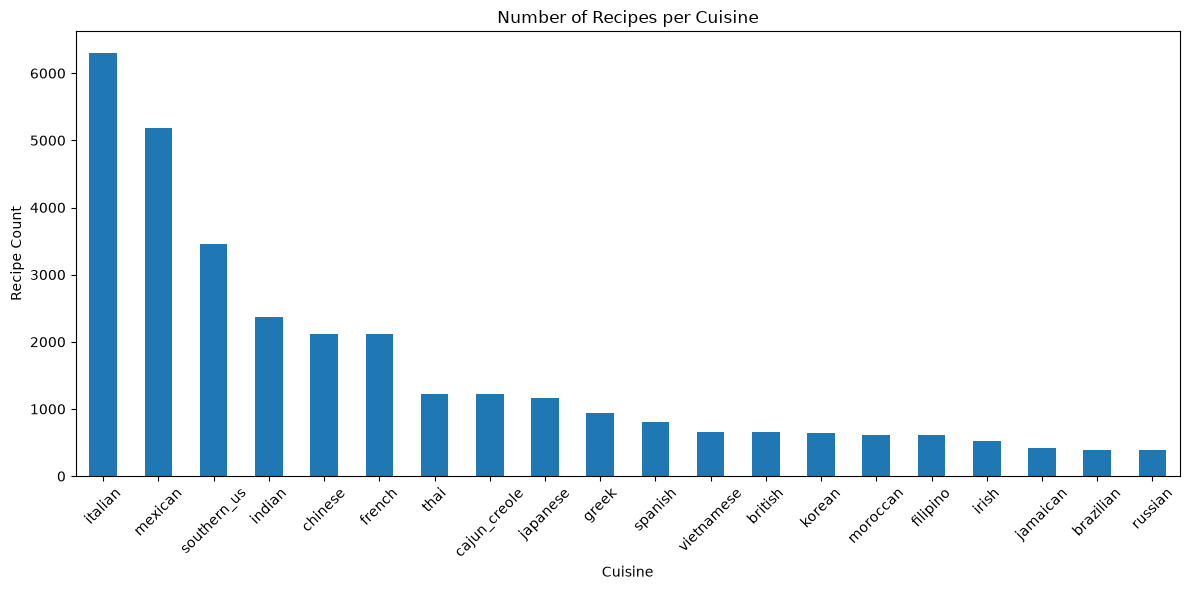

In [194]:
plt.figure(figsize=(12,6))
cuisine_counts.plot(kind="bar")

plt.title("Number of Recipes per Cuisine")
plt.xlabel("Cuisine")
plt.ylabel("Recipe Count")
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

Most Common Ingredients

In [195]:

ingredient_counts = Counter(
    ingredient.lower()
    for recipe in data
    for ingredient in recipe['ingredients']
)

pd.DataFrame(
    ingredient_counts.most_common(20),
    columns=["Ingredient", "Count"]
)

,Ingredient,Count
0,salt,14366
1,onions,6365
2,olive oil,6356
3,water,5963
4,garlic,5868
5,sugar,5155
6,garlic cloves,5032
7,ground black pepper,3860
8,butter,3859
9,all-purpose flour,3705


# 3. Preprocessing

In [196]:
print ("Divide into training and validation sets")
X_train, X_test, y_train, y_test = train_test_split(X, Y, test_size=0.20, random_state=42)

Divide into training and validation sets


REGEX portion:

I decided to use reg ex library (https://docs.python.org/3/library/re.html). I primarily  Wanted to do this to implement Multiword Expressions

For example, I noticed a couple ingredients consist of two words, but they aren't connected via underscore, so they're treated differently. ex: soy and sauce should be one token

I also wanted to implement synonym replacement/mapping, as some ingredients are the same thing. Like cilantro and coriander, and scallions, spring onions, and green onions.

HOWEVER, not all MWE/mapping to a target word is useful. Mapping garbanzo beans to chickpeas and transforming soy sauce to soy_sauce lowered results (accuracy, f1, precision) across the board. This is likely because although they are technically the same ingredient, different cultures will refer to the same ingredient differently in their recipes.

By just doing some light research, I found that the word "chickpea" is found in English/Western usage, and garbanzo beans are used more in Spanish-speaking cultures.

This is just a hypothesis, so I would like to analyze the results of the most-used ingredients in each cuisine to see if this is correct later on.





In [ ]:
_PATTS = [
    # Cilantro is coriander, decided to group these two
    (re.compile(r"\bcoriander\b", re.I), "cilantro"),
    # scallions, spring onions, green onions should all be grouped into green_onion
    (re.compile(r"\b(scallions?|spring\s+onions?|green\s+onions?)\b", re.I), "green_onion"),
    # soy and sauce should be one phrase, soy_sauce
    (re.compile(r"\bsoy\s+sauce\b", re.I), "soy_sauce"),
    # chickpea and garbanzo beans are the same thing, so group them into chickpea
   # (re.compile(r"\b(chickpeas?|garbanzo\s+beans?)\b", re.I), "chickpea"),
    
    # fish sauce -> fish_sauce
   # (re.compile(r"\bfish\s+sauce\b", re.I), "fish_sauce"), # *lowered results, didn't implement

    # jerk seasoning -> jerk_seasoning
   (re.compile(r"\bjerk(\s+seasoning)?\b", re.I), "jerk_seasoning"),
]

In [198]:
def preprocess(s: str) -> str:
    s = s.lower()
    for rx, rep in _PATTS:
        s = rx.sub(rep, s)
    return s

In [199]:
for i in range(5):
    print("Cuisine:", Y[i])
    print("Original:", data[i]["ingredients"])
    print("Processed:", X[i])
    print()

Cuisine: greek
Original: ['romaine lettuce', 'black olives', 'grape tomatoes', 'garlic', 'pepper', 'purple onion', 'seasoning', 'garbanzo beans', 'feta cheese crumbles']
Processed: romaine lettuce black olives grape tomatoes garlic pepper purple onion seasoning garbanzo beans feta cheese crumbles

Cuisine: filipino
Original: ['eggs', 'pepper', 'salt', 'mayonaise', 'cooking oil', 'green chilies', 'grilled chicken breasts', 'garlic powder', 'yellow onion', 'soy sauce', 'butter', 'chicken livers']
Processed: eggs pepper salt mayonaise cooking oil green chilies grilled chicken breasts garlic powder yellow onion soy sauce butter chicken livers

Cuisine: indian
Original: ['water', 'vegetable oil', 'wheat', 'salt']
Processed: water vegetable oil wheat salt

Cuisine: indian
Original: ['black pepper', 'shallots', 'cornflour', 'cayenne pepper', 'onions', 'garlic paste', 'milk', 'butter', 'salt', 'lemon juice', 'water', 'chili powder', 'passata', 'oil', 'ground cumin', 'boneless chicken skinless 

# 4. LinearSVC model

In [200]:
# Built a modeling pipeleine, the TfidfVectorizer turns text numeric
# min_df = 4, so this ignores words that appear in fewer than 4 documents 
# min_df of 4 gave me the best test accuracy and had the best CM 
# Linear SVC (support vector classification)
# implements the preprocessor function from last cell
# ngram_range of 1,1 (1,2 yielded worse results)
# * class weight balanced because I noticed that cuisines like Italian or Thai had high accuracy,
# but other cuisines were very inaccurately matched
pipe = Pipeline([
    ("vec", TfidfVectorizer(
        preprocessor = preprocess,                 
        token_pattern=r"(?u)\b\w[\w_]+\b",          
        min_df=1, ngram_range=(1,1)
    )),
    ("clf", LinearSVC(C=1.0))
])

param_grid = {"clf__C": [0.5, 1.0, 2.0]}
cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)
gs = GridSearchCV(pipe, param_grid, cv=cv, n_jobs=-1, verbose=1)
gs.fit(X_train, y_train)

print("Best params:", gs.best_params_)
print("Test accuracy:", gs.score(X_test, y_test))

Fitting 3 folds for each of 3 candidates, totalling 9 fits
Best params: {'clf__C': 0.5}
Test accuracy: 0.7968258956631049


In [201]:
y_pred = gs.best_estimator_.predict(X_test)
print("Accuracy:", accuracy_score(y_test, y_pred))
print("Macro F1:", f1_score(y_test, y_pred, average="macro", zero_division=0))
print("Weighted F1:", f1_score(y_test, y_pred, average="weighted", zero_division=0))
print("Macro Precision:", precision_score(y_test, y_pred, average="macro", zero_division=0))
print("Macro Recall:", recall_score(y_test, y_pred, average="macro", zero_division=0))

Accuracy: 0.7968258956631049
Macro F1: 0.7283391457950973
Weighted F1: 0.7928958944627805
Macro Precision: 0.7688893570654434
Macro Recall: 0.701152103488446


Overall all metrics are >.70 which I'm happy with so far.

Weighted F1 is .07 points above Macro F1 which indicates that smaller cuisines are doing worse. I would like to smooth this out.

*Note: Least represented cuisines: Jamaican, Brazilian, Russian

# 5. Further analysis of results, errors, and data

Let us look at a classification report for every cuisine.

In [202]:
report = classification_report(
	y_test,
	y_pred,
	digits=3,
	zero_division=0,
	output_dict=True
)

# convert to DataFrame and transpoise
df = pd.DataFrame(report).T

summary_rows = ['accuracy', 'macro avg', 'weighted avg']
class_df = df.drop(index=summary_rows)

sorted_df = class_df.sort_values(by='f1-score', ascending=False)

print(sorted_df)

              precision    recall  f1-score  support
mexican        0.899261  0.925785  0.912330   1051.0
indian         0.863445  0.895425  0.879144    459.0
jamaican       0.867647  0.867647  0.867647     68.0
italian        0.820128  0.895557  0.856185   1283.0
chinese        0.827815  0.878220  0.852273    427.0
moroccan       0.869919  0.798507  0.832685    134.0
korean         0.813559  0.750000  0.780488    128.0
thai           0.775934  0.782427  0.779167    239.0
japanese       0.882682  0.689956  0.774510    229.0
southern_us    0.721311  0.790055  0.754120    724.0
cajun_creole   0.750000  0.756757  0.753363    222.0
greek          0.796296  0.701087  0.745665    184.0
vietnamese     0.685714  0.615385  0.648649    117.0
french         0.626126  0.642032  0.633979    433.0
filipino       0.653846  0.581197  0.615385    117.0
brazilian      0.854167  0.476744  0.611940     86.0
russian        0.686275  0.530303  0.598291     66.0
spanish        0.663934  0.525974  0.586957   

Jamaican F1 score is actally incredible, no problems there. I suspected that was the regex of changing jerk seasong to jerk_seasoning, but there was no change when I deleted it.

While that regex does improve the metrics overall, it has no effect on jamaican cuisine itself - but it does have an effect on mexican precision (going from .89 to .90), which is interesting

cuisines to focus on: Brazilian, Russian, Spanish, British, and Irish

Error-Analysis Table

In [203]:
results_df = pd.DataFrame({
 "ingredients": X_test,
 "actual_cuisine": y_test,
 "predicted_cuisine": y_pred
})
errors_df = results_df[
 results_df["actual_cuisine"] != results_df["predicted_cuisine"]
].copy()

print("Number of recipes:" , len(results_df))
print("Number of misclassified recipes:", len(errors_df))
print("Misclassified recipes:")
print(errors_df)

Number of recipes: 6364
Number of misclassified recipes: 1293
Misclassified recipes:
                                            ingredients actual_cuisine  \
0     black pepper chopped green bell pepper garlic ...   cajun_creole   
5     seasoning pork sirloin chops pepper panko brea...         korean   
8     sugar hot water butter orange juice bourbon wh...        british   
11    brandy lemon orange juice lime dry red wine wh...        spanish   
17    vegetable oil ground cumin boneless chicken br...        mexican   
...                                                 ...            ...   
6342  globe eggplant tahini rice vinegar light soy s...        chinese   
6345  nonfat dry milk powder white sugar water cumin...         indian   
6346  ground nutmeg paprika ground white pepper eggs...    southern_us   
6351  lemon grass chopped cilantro lime chopped fres...     vietnamese   
6362  water salt butter cinnamon sugar large eggs al...        mexican   

     predicted_cuisine  
0

misclassified recipes / all recipes = 1293 / 6364 = .20

So 1/5 recipes were misclassified

The ingredients most associated with each cuisine

In [204]:
import numpy as np

best_model = gs.best_estimator_

vectorizer = best_model.named_steps['vec']
classifier = best_model.named_steps['clf']

feature_names = np.array(vectorizer.get_feature_names_out()
                         )

for class_index,cuisine in enumerate(classifier.classes_):
    top10_indices = np.argsort(classifier.coef_[class_index])[-10:]
    top10_features = feature_names[top10_indices]
    print(f"Top 10 features for {cuisine}: {top10_features}")

Top 10 features for brazilian: ['cassava' 'palm' 'passion' 'sprinkles' 'granola' 'tapioca' 'manioc'
 'dende' 'açai' 'cachaca']
Top 10 features for british: ['jam' 'malt' 'dates' 'cheddar' 'worcestershire' 'haddock' 'marmite'
 'mincemeat' 'suet' 'stilton']
Top 10 features for cajun_creole: ['andouille' 'blackening' 'mirlitons' 'sausage' 'shrimp' 'jambalaya'
 'cayenne' 'celery' 'creole' 'cajun']
Top 10 features for chinese: ['custard' 'shaoxing' 'ginger' 'hoisin' 'mein' 'soy_sauce' 'mandarin'
 'chinese' 'fermented' 'szechwan']
Top 10 features for filipino: ['eggplant' 'soy_sauce' 'annatto' 'edam' 'garlic' 'patis' 'sprite' 'dogs'
 'lumpia' 'calamansi']
Top 10 features for french: ['burgundy' 'snails' 'duck' 'calvados' 'niçoise' 'crepes' 'cognac' 'swiss'
 'gruyère' 'gruyere']
Top 10 features for greek: ['kefalotyri' 'dill' 'oregano' 'tzatziki' 'lamb' 'ouzo' 'tahini' 'phyllo'
 'greek' 'feta']
Top 10 features for indian: ['basmati' 'naan' 'chutney' 'curds' 'yoghurt' 'cardamom' 'tandoori'
 'y

# Garbanzo Beans vs. Chickpeas Test: Which ingredient correlates with which cuisine(s)? 

Although these terms describe the same ingredient, merging them reduced model performance. Which cuisines lean towards which term?

In [205]:
# use original dataset, no preprocessing
# more info on Collections Counter: https://www.geeksforgeeks.org/python/counters-in-python-set-1/
garbanzo_count= Counter()
chickpea_count = Counter()

for recipe in data:
    cuisine = recipe['cuisine']
    raw_ingredients = [
        ingredient.lower()
        for ingredient in recipe['ingredients']
    ]

    if any ("garbanzo beans" in  ingredient for ingredient in raw_ingredients):
        garbanzo_count[cuisine] += 1

    if any ("chickpeas" in ingredient for ingredient in raw_ingredients):
        chickpea_count[cuisine] += 1
    

In [206]:
term_comparison = pd.DataFrame({
    "garbanzo_recipes": pd.Series(garbanzo_count),
    "chickpea_recipes": pd.Series(chickpea_count)
}).fillna(0).astype(int)

term_comparison["total_recipes"] = (
    term_comparison["garbanzo_recipes"] + term_comparison["chickpea_recipes"]
)

term_comparison.sort_values(
    "total_recipes",
    ascending = False
)


,garbanzo_recipes,chickpea_recipes,total_recipes
indian,29,113,142
moroccan,28,93,121
greek,19,30,49
italian,16,26,42
mexican,14,13,27
spanish,7,19,26
french,1,9,10
thai,1,5,6
cajun_creole,2,3,5
filipino,4,1,5


Leans Chickpeas: Indian, Moroccan, Greek, Italian, Spanish, French, Thai
Leans Garbanzo Beans: Mexican (barely), Filipino, 

In [210]:
#let's look at 20 predictions

for i in range(20):
    print(X_test[i],'|',y_test[i],'|',y_pred[i],'\n')

black pepper chopped green bell pepper garlic cloves italian salad dressing bouillon cube long-grain rice olive oil flavored cooking spray olive oil chopped onion boneless skinless chicken breast halves turkey breakfast sausage chopped celery hot water sliced green onions | cajun_creole | italian 

fresh cilantro salt stewed tomatoes chopped fresh chives serrano pepper garlic | mexican | mexican 

coriander seeds salt ghee saffron threads whole milk yoghurt cumin seed milk garlic fresh lemon juice fresh ginger root cayenne pepper chicken thighs | indian | indian 

mayonaise flour tortillas olive oil chipotle peppers shredded cheddar cheese salt asparagus | mexican | mexican 

bread giblet ground cayenne pepper oysters salt cooked white rice pepper chopped celery chopped parsley vegetable oil chopped onion | cajun_creole | cajun_creole 

seasoning pork sirloin chops pepper panko breadcrumbs eggs salt flour canola oil | korean | japanese 

green onions chili shredded cheddar cheese cream

In [211]:
class_names =[]
for i in range(len(y_test)):
    if y_test[i] not in class_names:
        class_names.append(y_test[i])

In [212]:
import matplotlib.pyplot as plt
def plot_confusion_matrix(cm, classes,
                          normalize=False,
                          title='Confusion matrix',
                          cmap=plt.cm.Blues):
    """
    This function prints and plots the confusion matrix.
    Normalization can be applied by setting `normalize=True`.
    """
    if normalize:
        cm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]

    plt.imshow(cm, interpolation='nearest', cmap=cmap)
    plt.title(title)
    plt.colorbar()
    tick_marks = np.arange(len(classes))
    plt.xticks(tick_marks, classes, rotation=45)
    plt.yticks(tick_marks, classes)

    fmt = '.2f' if normalize else 'd'
    thresh = cm.max() / 2.
    for i, j in itertools.product(range(cm.shape[0]), range(cm.shape[1])):
        plt.text(j, i, format(cm[i, j], fmt),
                 horizontalalignment="center",
                 color="white" if cm[i, j] > thresh else "black")

    plt.ylabel('True label')
    plt.xlabel('Predicted label')
    plt.tight_layout()

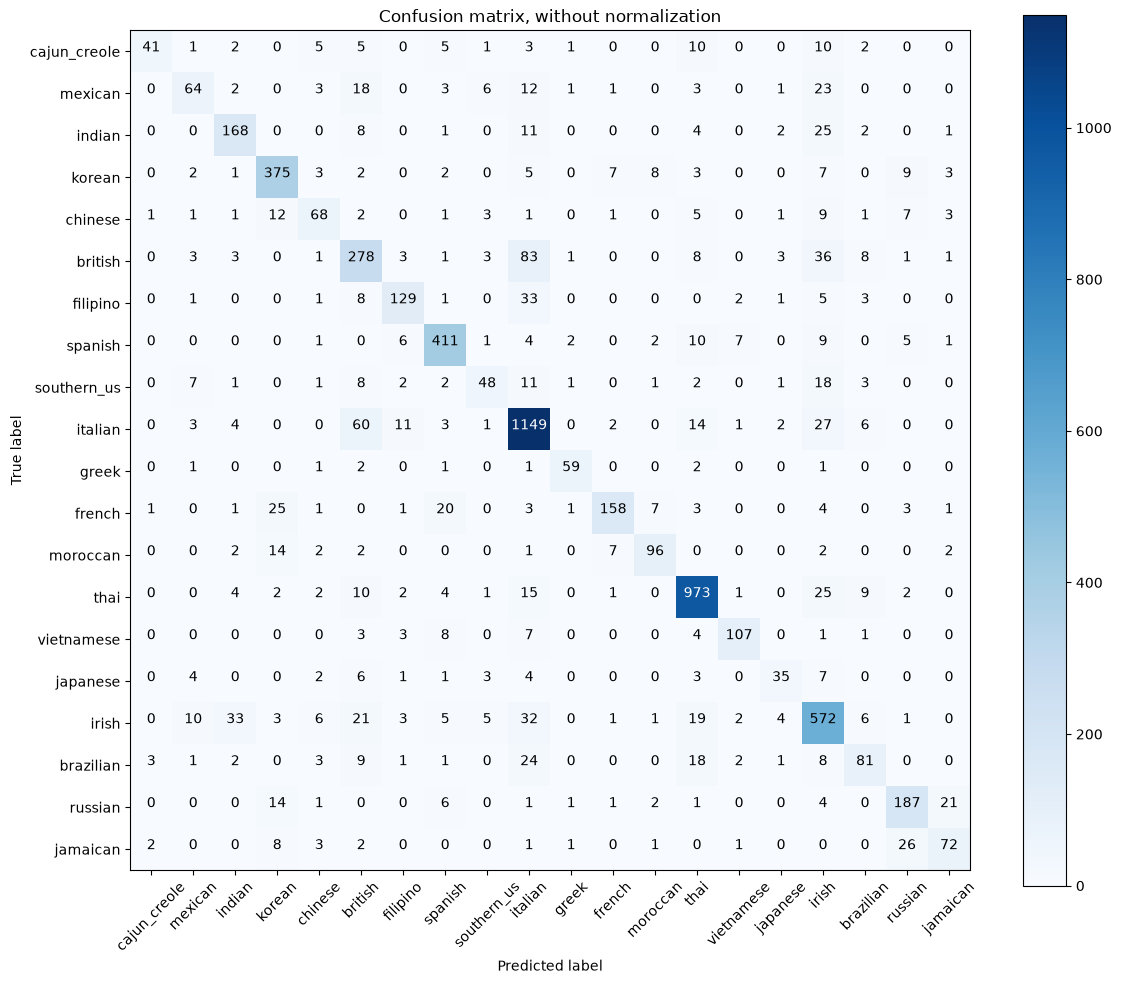

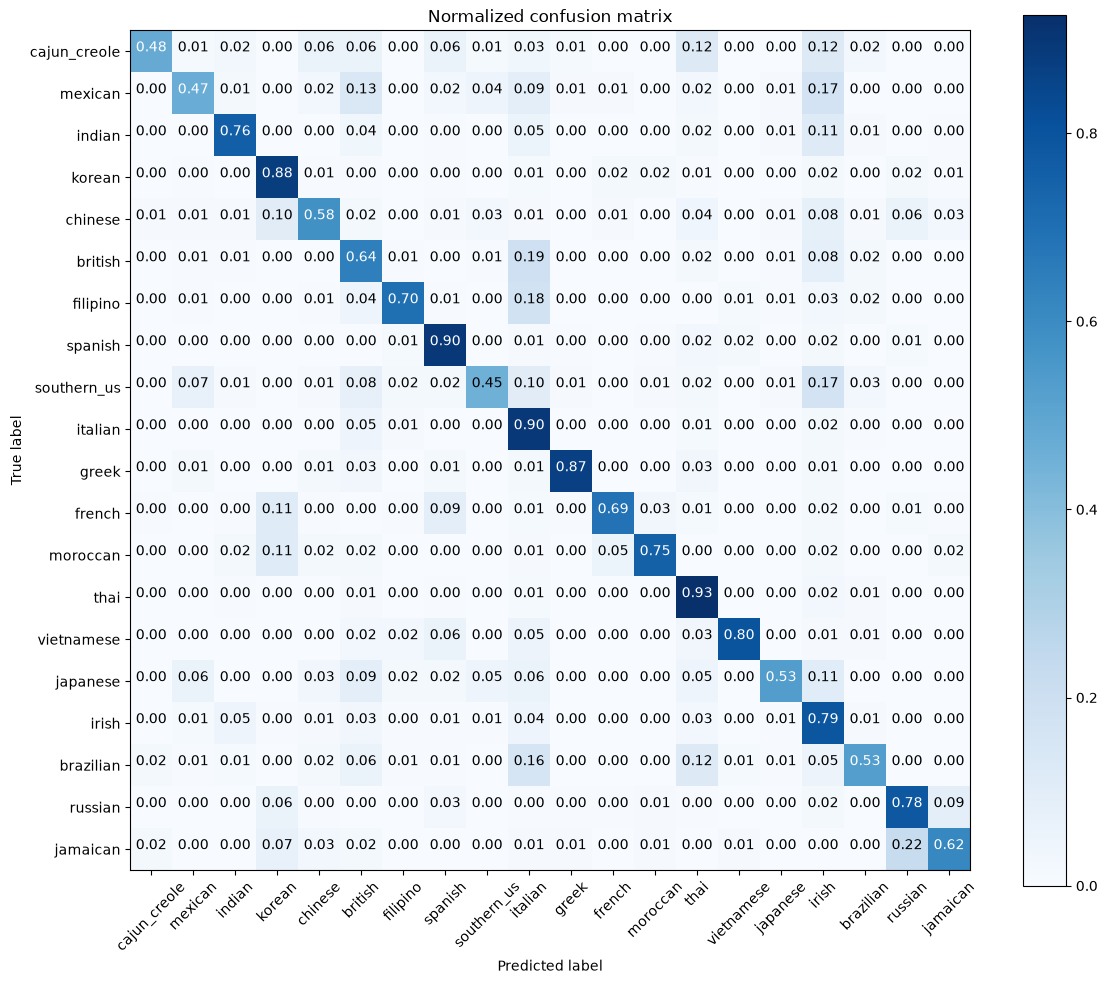

In [213]:
cnf_matrix = confusion_matrix(y_test, y_pred)
np.set_printoptions(precision=2)

# Plot non-normalized confusion matrix
plt.figure(figsize=(12, 10))
plot_confusion_matrix(cnf_matrix, classes=class_names,
                      title='Confusion matrix, without normalization')

#plt.savefig("figure1.pdf", dpi="figure")
# Plot normalized confusion matrix
plt.figure(figsize=(12, 10))
plot_confusion_matrix(cnf_matrix, classes=class_names, normalize=True,
                      title='Normalized confusion matrix')

#plt.savefig("figure2.pdf", dpi="figure")
plt.show()

In [214]:


with open("data/cooking_testfile.json", "r", encoding="utf-8") as f:
    data = json.load(f)

ids   = [d["id"] for d in data]
texts = [", ".join(d["ingredients"]) for d in data]  # <-- was the bug

best = gs.best_estimator_
pred = best.predict(texts)
out = pd.DataFrame({"id": ids, "cuisine": pred})

# Creates new output file, uncomment to download
#out.to_csv("data/cooking_output.csv", index=False)
print("Wrote cooking_output.csv with", len(out), "rows; last id:", out.iloc[-1,0])



Wrote cooking_output.csv with 7955 rows; last id: 905668
